# Adult Census Income Analysis

# Exploratory Data Analysis (EDA)

### Data Dictionary

| Column | Description |
|:-------|:------------|
| `age` | Age of the individual in years. |
| `workclass` | Employment sector or type of employer. |
| `fnlwgt` | Final Weight assigned by the U.S. Census Bureau. It estimates how many people in the overall population this individual represents and serves as a sampling weight. |
| `education` | Highest education level completed by the individual. |
| `education_num` | Numeric representation of the education level. Higher values indicate higher educational attainment. |
| `marital_status` | Current marital status of the individual. |
| `occupation` | Occupation or job category of the individual. |
| `relationship` | Relationship status within the household. |
| `race` | Self-reported racial category of the individual. |
| `sex` | Biological sex of the individual (Male or Female). |
| `capital_gain` | Annual capital gains from investments or asset sales. A value of **0** indicates no capital gain. |
| `capital_loss` | Annual capital losses from investments or asset sales. A value of **0** indicates no capital loss. |
| `hours_per_week` | Average number of hours worked per week. |
| `native_country` | Country of origin or birth of the individual. |
| `income` | Target variable indicating whether annual income is **>50K** or **<=50K**. |

### Importing Necessary Libraries

In [1]:
from edatoolkit import EDA
import pandas as pd
import numpy as np

print('Libraries imported sucessfully!')

Libraries imported sucessfully!


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [4]:
from database.database import DataBase_Manager

In [5]:
dbm=DataBase_Manager()
df=dbm.load_table('census_income')

Using the `DataBase_Manager()` class, we pull the data from the dockerized MySQL and inspect the `head()`.

In [6]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [7]:
eda=EDA(dataframe=df,target_col='income',cat_th=20)

In [8]:
eda.check_dataframe()


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                   Head                                                                                   
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   age workclass  fnlwgt     education  education.num marital.status         occupation   relationship   race     sex  capital.gain  capital.loss  hours.per.week native.country income
0   90         ?   77053       HS-grad              9        Widowed                  ?  Not-in-family  White  Female             0          4356              40  United-States  <=50K
1   82   Private  132870       HS-grad              9        Widowed    Exec-managerial  Not-in-family  White  Female 

 We have completed the initial data inspection using our `edatoolkit` Python package. The overview reveals that the dataset contains 15 columns and more than 32,000 rows. Additionally, we identified a very small number of duplicate records.

In [9]:
cat_cols,num_cols,num_but_cat,cat_but_car=eda.get_columns_types()

In [10]:
print(f'Categorical columns: {cat_cols}')
print(f'Numerical columns: {num_cols}')
print(f'Numerical but categorical columns: {num_but_cat}')
print(f'Categorical but cardinal columns: {cat_but_car}')

Categorical columns: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'income', 'education.num']
Numerical columns: ['age', 'fnlwgt', 'capital.gain', 'capital.loss', 'hours.per.week']
Numerical but categorical columns: ['education.num']
Categorical but cardinal columns: ['native.country']


In this step, we checked and determined the data type of each column.

In [11]:
df[[*cat_cols,*cat_but_car]]=df[[*cat_cols,*cat_but_car]].astype('category')
df=df.drop_duplicates()
eda.update_dataframe(df)

Dataframe and column types have been successfully updated.


We then converted the categorical columns to the `category` data type using `astype()` and removed the duplicate rows. Finally, we updated `self.dataframe` using the `update_dataframe` method from the `edatoolkit` package.

## Data Quality Check/Data Cleaning

In [12]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [13]:
wife_check = df[df['relationship'] == 'Wife']['sex'].value_counts()
print("Wife - sex check:")
print(wife_check)


husband_check = df[df['relationship'] == 'Husband']['sex'].value_counts()
print("\nHusband - sex check:")
print(husband_check)

Wife - sex check:
sex
Female    1566
Male         2
Name: count, dtype: int64

Husband - sex check:
sex
Male      13186
Female        1
Name: count, dtype: int64


In [14]:
df=df[~((df['relationship']=='Wife') & (df['sex']=='Male')) & ~((df['relationship'] == 'Husband') & (df['sex']=='Female'))]

We specifically filtered out logical contradictions, such as records where `Sex` is `Male` but the status is `Wife`, and vice versa (`Female` and `Husband`). Since these anomalies represented a negligible portion of the data, removing them does not impact our overall sample size. Furthermore, dropped rows were preferred over manual imputation because it is impossible to determine whether the error lies in the `Sex` column or the marital status attribute.

In [15]:
edu_check = df.groupby(['education', 'education.num']).size().reset_index(name='count')
edu_check

,education,education.num,count
0,10th,6,933
1,11th,7,1175
2,12th,8,433
3,1st-4th,2,166
4,5th-6th,3,332
5,7th-8th,4,645
6,9th,5,514
7,Assoc-acdm,12,1067
8,Assoc-voc,11,1382
9,Bachelors,13,5351


In [16]:
edu_check = df.groupby('education')['education.num'].nunique()
print(edu_check[edu_check > 1])  

Series([], Name: education.num, dtype: int64)


Next, we cross-checked the `education` and `education.num` columns to ensure there were no structural inconsistencies between them, as they represent the same underlying information. The verification confirmed that all values align perfectly across both features.

In [17]:
df.groupby(['marital.status', 'relationship']).size().reset_index(name='count')

,marital.status,relationship,count
0,Divorced,Not-in-family,2403
1,Divorced,Other-relative,110
2,Divorced,Own-child,328
3,Divorced,Unmarried,1600
4,Married-AF-spouse,Husband,9
5,Married-AF-spouse,Other-relative,1
6,Married-AF-spouse,Own-child,1
7,Married-AF-spouse,Wife,12
8,Married-civ-spouse,Husband,13177
9,Married-civ-spouse,Not-in-family,17


In [18]:
df = df[~((df['marital.status'] == 'Married-civ-spouse') & (df['relationship'] == 'Other-relative')) 
        & ~((df['marital.status'] == 'Married-civ-spouse') & (df['relationship'] == 'Not-in-family'))]

Additionally, we identified several inconsistencies between the `marital.status` and `relationship` columns. To preserve the reliability of our data, these mismatched records were successfully cleaned and removed.

In [19]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Missing Value Analysis

In [20]:
(df=='?').any()

age               False
workclass          True
fnlwgt            False
education         False
education.num     False
marital.status    False
occupation         True
relationship      False
race              False
sex               False
capital.gain      False
capital.loss      False
hours.per.week    False
native.country     True
income            False
dtype: bool

We then moved on to the missing value analysis phase. In this step, we checked for the presence of missing values placeholder symbols (specifically `?`) and identified which columns contained them.

In [21]:
df[(df=='?').any(axis=1)]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K
14,51,?,172175,Doctorate,16,Never-married,?,Not-in-family,White,Male,0,2824,40,United-States,>50K
18,22,Private,119592,Assoc-acdm,12,Never-married,Handlers-cleaners,Not-in-family,Black,Male,0,2824,40,?,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32533,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32534,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32541,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K
32543,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [22]:
df = df.replace("?", np.nan)
df[cat_cols+cat_but_car] = df[cat_cols+cat_but_car].astype('object')

 Our analysis revealed that the `?` placeholders were present exclusively within the categorical columns. To facilitate the cleaning process, we temporarily converted these features to the `object` data type. This step prevents Pandas from retaining unused categories with a frequency of zero after filtering, which would otherwise complicate further analysis.

## Missing Value Imputation Using Machine Learning

 In this section, instead of using traditional statistical methods like mode or frequent category replacement, we leverage machine learning algorithms to predict and impute the missing values in our categorical columns. This advanced approach preserves the underlying distribution and relationships within the dataset.

Importing Necessary Libraries

In [23]:
from lightgbm import LGBMClassifier
print('Libraries imported sucessfully!')

Libraries imported sucessfully!


At this stage of the EDA, our priority is efficient missing value imputation rather than fine-tuning complex architectures or running extensive hyperparameter grids. To keep the pipeline both fast and accurate, we utilize **LightGBM**, which serves as an exceptionally powerful and high-speed baseline model for this specific task.

In [24]:
df[['workclass', 'occupation', 'native.country']].isnull().sum()

workclass         1828
occupation        1835
native.country     580
dtype: int64

We initiate the imputation process starting with the column that has the lowest number of missing values. This iterative approach ensures that as we move forward to predict more complex missing patterns, the previously imputed columns can be effectively utilized as fully complete features to train subsequent models.

In [25]:
def imputer(df, col_name, cat_cols, num_cols):
    all_features = col_name + cat_cols + num_cols
    
    df_2 = df[all_features].copy()
    for col in cat_cols:
        df_2[col] = df_2[col].astype('category')
        
    train_df = df_2[~df_2.isnull().any(axis=1)]

    test_df = df_2[df_2.isnull().any(axis=1)]
    indexes=test_df.index
    

    X_train = train_df.drop(columns=col_name[0])
    X_test = test_df.drop(columns=col_name[0])
    y_train = train_df[col_name[0]] 
    model = LGBMClassifier(verbosity=-1, force_row_wise=True)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    ser=pd.Series(pred)
    ser.name=col_name[0]
    pred=pd.DataFrame(ser).set_index(indexes)
    df[col_name[0]] = df[col_name[0]].fillna(pred[col_name[0]])
    
    return df

  To ensure a clean execution without redundant logs, we pass specific configurations to LightGBM to suppress unnecessary warnings. Additionally, we explicitly cast all categorical features to the `category` dtype; this allows LightGBM to natively recognize and handle them, completely eliminating the need for manual encoding steps like One-Hot or Label Encoding. 

 For each iteration, the model is trained exclusively on the non-null rows of the target column. It then predicts the missing values (`NaN`s) for the remaining rows and directly imputes them back into the original dataframe.

In [26]:
df=imputer(df,['native.country'],['education','marital.status','relationship','race','sex','income','education.num'],num_cols)

In [27]:
df=imputer(df,['workclass'],['native.country','education','marital.status','relationship','race','sex','income','education.num'],num_cols)

In [28]:
df=imputer(df,['occupation'],['workclass','native.country','education','marital.status','relationship','race','sex','income','education.num'],num_cols)

In [29]:
eda.update_dataframe(new_df=df)

Dataframe and column types have been successfully updated.


 Finally, we update the dataframe once again to ensure all changes are permanently applied.

In [30]:
eda.check_dataframe()


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                   Head                                                                                   
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   age workclass  fnlwgt     education education.num marital.status         occupation   relationship   race     sex  capital.gain  capital.loss  hours.per.week native.country income
0   90   Private   77053       HS-grad             9        Widowed       Adm-clerical  Not-in-family  White  Female             0          4356              40  United-States  <=50K
1   82   Private  132870       HS-grad             9        Widowed    Exec-managerial  Not-in-family  White  Female    

In [31]:
df=df.drop_duplicates()
eda.update_dataframe(new_df=df)
eda.check_dataframe()

Dataframe and column types have been successfully updated.

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                   Head                                                                                   
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   age workclass  fnlwgt     education education.num marital.status         occupation   relationship   race     sex  capital.gain  capital.loss  hours.per.week native.country income
0   90   Private   77053       HS-grad             9        Widowed       Adm-clerical  Not-in-family  White  Female             0          4356              40  United-States  <=50K
1   82   Private  132870       HS-grad             9        W

In [32]:
cat_cols,num_cols,num_but_cat,cat_but_car=eda.get_columns_types()

## Categorical Feature Analysis


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                       Categorical Variable Summary                                                                       
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Column: workclass
                  Count      Ratio
workclass                         
Private           24169  74.614102
Self-emp-not-inc   2644   8.162509
Local-gov          2117   6.535564
State-gov          1319   4.071993
Self-emp-inc       1126   3.476167
Federal-gov         976   3.013090
Without-pay          31   0.095703
Never-worked         10   0.030872


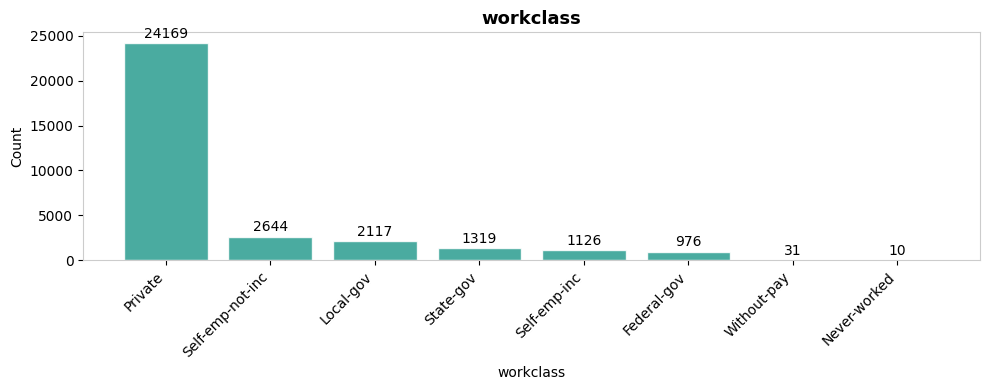


Column: education
              Count      Ratio
education                     
HS-grad       10452  32.267226
Some-college   7262  22.419116
Bachelors      5329  16.451593
Masters        1717   5.300692
Assoc-voc      1375   4.244875
11th           1169   3.608916
Assoc-acdm     1064   3.284762
10th            931   2.874166
7th-8th         641   1.978884
Prof-school     575   1.775130
9th             508   1.568288
12th            426   1.315140
Doctorate       412   1.271919
5th-6th         324   1.000247
1st-4th         160   0.493949
Preschool        47   0.145098


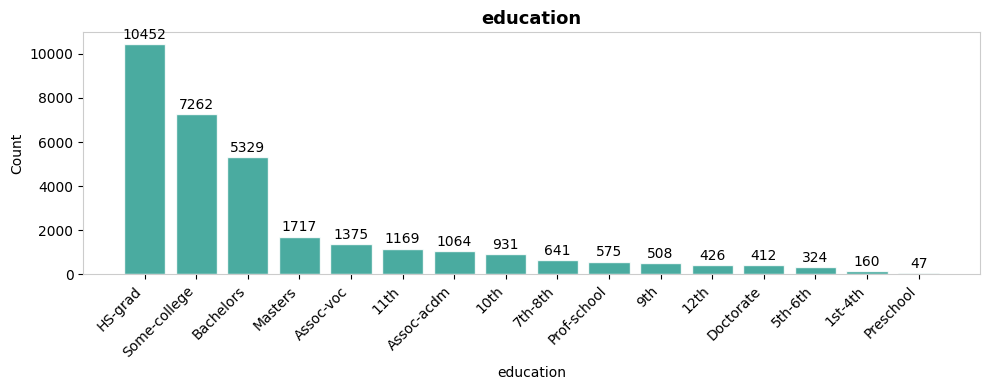


Column: education.num
               Count      Ratio
education.num                  
9              10452  32.267226
10              7262  22.419116
13              5329  16.451593
14              1717   5.300692
11              1375   4.244875
7               1169   3.608916
12              1064   3.284762
6                931   2.874166
4                641   1.978884
15               575   1.775130
5                508   1.568288
8                426   1.315140
16               412   1.271919
3                324   1.000247
2                160   0.493949
1                 47   0.145098


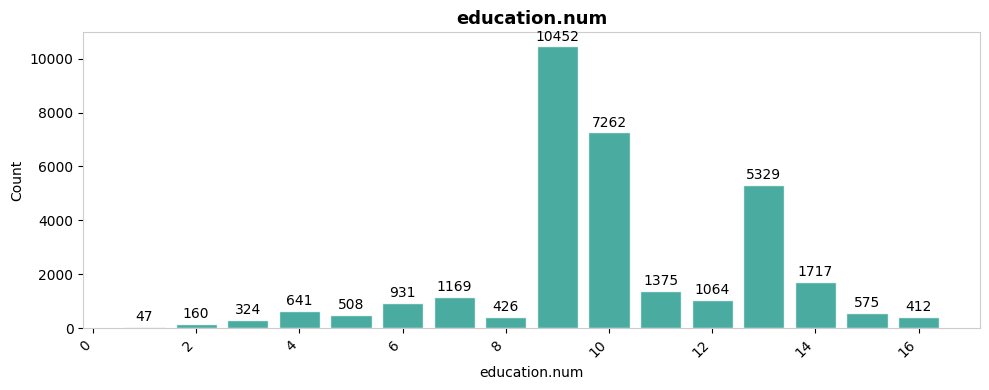


Column: marital.status
                       Count      Ratio
marital.status                         
Married-civ-spouse     14826  45.770561
Never-married          10666  32.927883
Divorced                4441  13.710175
Separated               1025   3.164362
Widowed                  993   3.065572
Married-spouse-absent    418   1.290442
Married-AF-spouse         23   0.071005


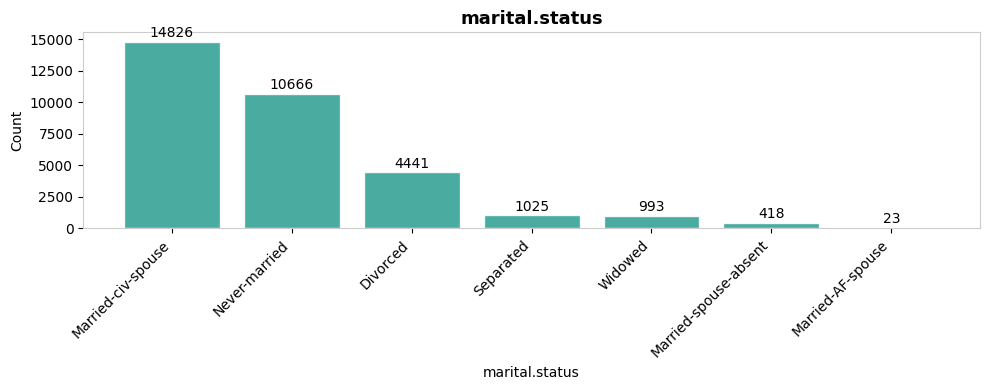


Column: occupation
                   Count      Ratio
occupation                         
Craft-repair        4343  13.407632
Prof-specialty      4301  13.277970
Exec-managerial     4171  12.876636
Adm-clerical        4055  12.518523
Sales               3859  11.913435
Other-service       3686  11.379353
Machine-op-inspct   2074   6.402816
Transport-moving    1642   5.069153
Handlers-cleaners   1426   4.402322
Farming-fishing     1053   3.250803
Tech-support         947   2.923561
Protective-serv      666   2.056063
Priv-house-serv      160   0.493949
Armed-Forces           9   0.027785


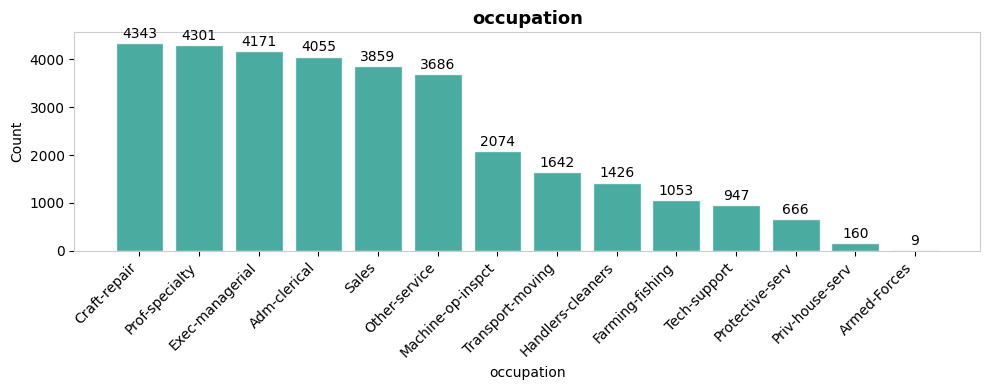


Column: relationship
                Count      Ratio
relationship                    
Husband         13186  40.707582
Not-in-family    8275  25.546431
Own-child        5063  15.630403
Unmarried        3445  10.635342
Wife             1566   4.834527
Other-relative    857   2.645715


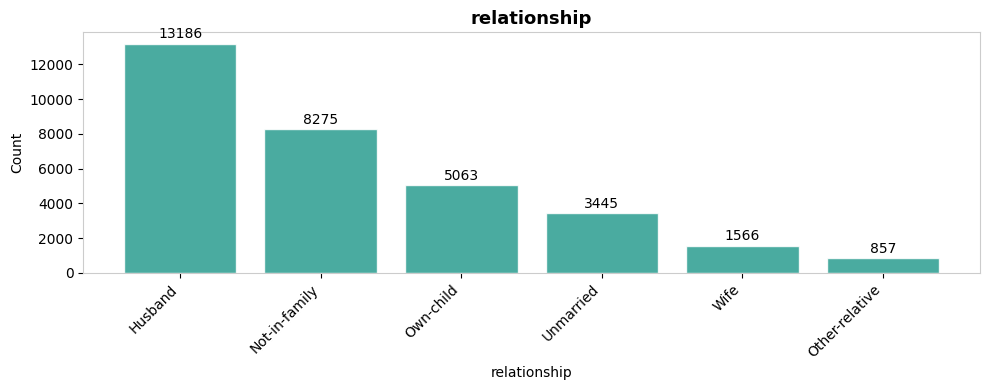


Column: race
                    Count      Ratio
race                                
White               27686  85.471721
Black                3115   9.616572
Asian-Pac-Islander   1018   3.142751
Amer-Indian-Eskimo    309   0.953939
Other                 264   0.815016


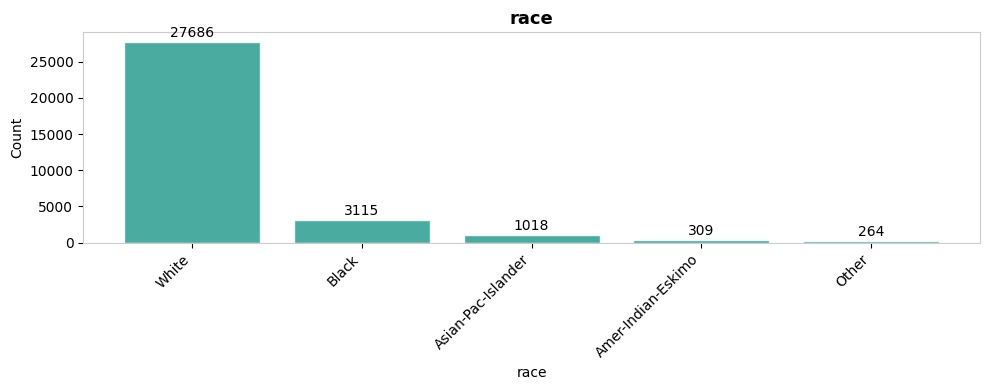


Column: sex
        Count      Ratio
sex                     
Male    21690  66.960978
Female  10702  33.039022


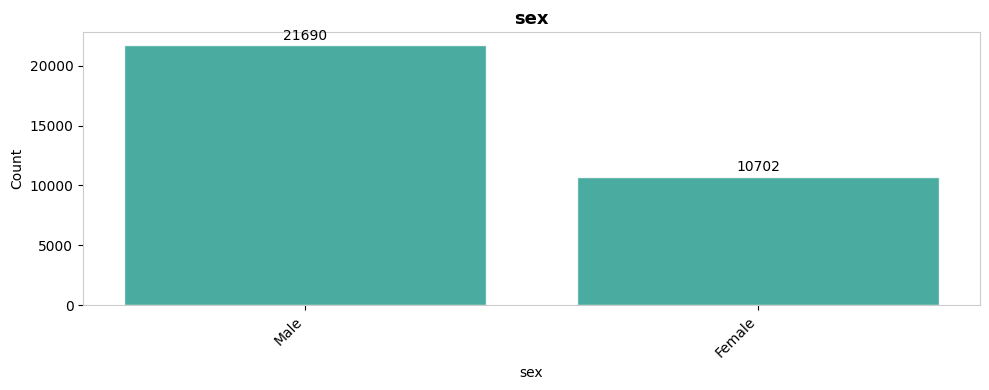


Column: income
        Count      Ratio
income                  
<=50K   24576  75.870585
>50K     7816  24.129415


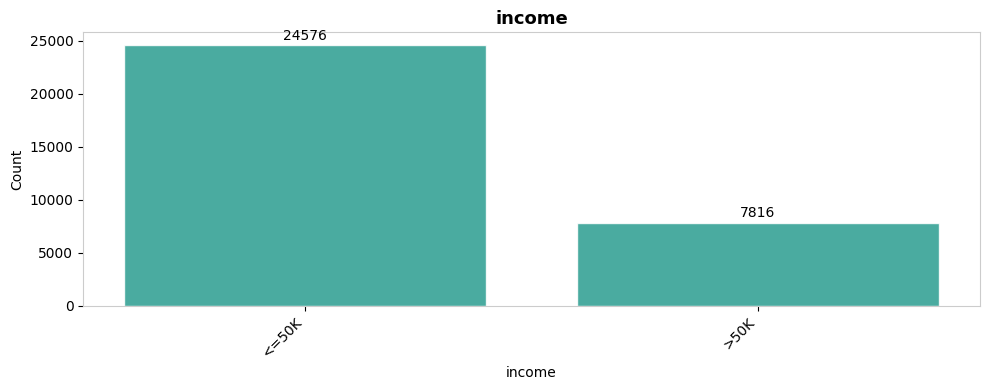

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [33]:
eda.cat_summary(plot=True,width_for_graph=10,height_for_graph=4)

 We utilized the `cat_summary()` method to inspect the distributions, counts, and overall balance of the values within our categorical columns. The output clearly indicates a severe class imbalance across several features, which we must take into account during subsequent modeling phases.

In [34]:
df['workclass'] = df['workclass'].replace( ['Never-worked', 'Without-pay'], 'Other')
df['occupation'] = df['occupation'].replace('Armed-Forces',  'Protective-serv')
df['marital.status'] = df['marital.status'].replace('Married-AF-spouse', 'Married-civ-spouse')
eda.update_dataframe(df)

Dataframe and column types have been successfully updated.


 To secure the validity of our Chi-Square tests, we isolated categories with an expected frequency lower than 5 or an absolute sample count below 30 as "rare" levels. Instead of blindly grouping all of them into a generic "Other" category, we utilized domain knowledge to merge logically related groups to preserve their underlying contextual meaning:

 * **Workclass:** Combined `Never-worked` and `Without-pay` into a unified `Other` group.
 * **Occupation:** Mapped `Armed-Forces` into the `Protective-serv` class due to professional similarity.
 * **Marital Status:** Merged `Married-AF-spouse` (Armed Forces spouse) into `Married-civ-spouse` (Civilian spouse), as both represent married households.

 Any remaining scattered micro-categories that did not fit a specific domain grouping were mapped directly to `Other`.

## Numerical Feature/Descriptive  Analysis

In [35]:
eda.descriptive_analysis()


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                           Descriptive Analysis                                                                           
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                  count           mean            std      min        1%        5%       25%       50%       75%       95%        99%        max    median      cv%   skewness    kurtosis
age             32392.0      38.601383      13.640372     17.0     17.00     19.00      28.0      37.0      48.0      63.0      74.00       90.0      37.0   35.336   0.556184   -0.170990
fnlwgt          32392.0  189713.892751  105559.564464  12285.0  27186.73  39422.55  117789.0  178333.5  236938.5

 By examining the skewness and kurtosis metrics, we can observe that none of the numerical variables follow a perfectly normal distribution. In fact, features like `capital.gain` and `capital.loss` exhibit extreme skewness and kurtosis values. 

Additionally, the Coefficient of Variation ($CV = \frac{\sigma}{\mu}$) is exceptionally high for these specific columns, indicating that the standard deviation is significantly larger than the mean. This mathematical pattern strongly implies that these features are zero-inflated; the vast majority of individuals have a value of 0, while only a small fraction of the population experiences capital gains or losses. In contrast, the remaining numerical columns show far less extreme behavior, with their mean and median values being relatively close to one another.


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                        Numerical Variable Summary                                                                        
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


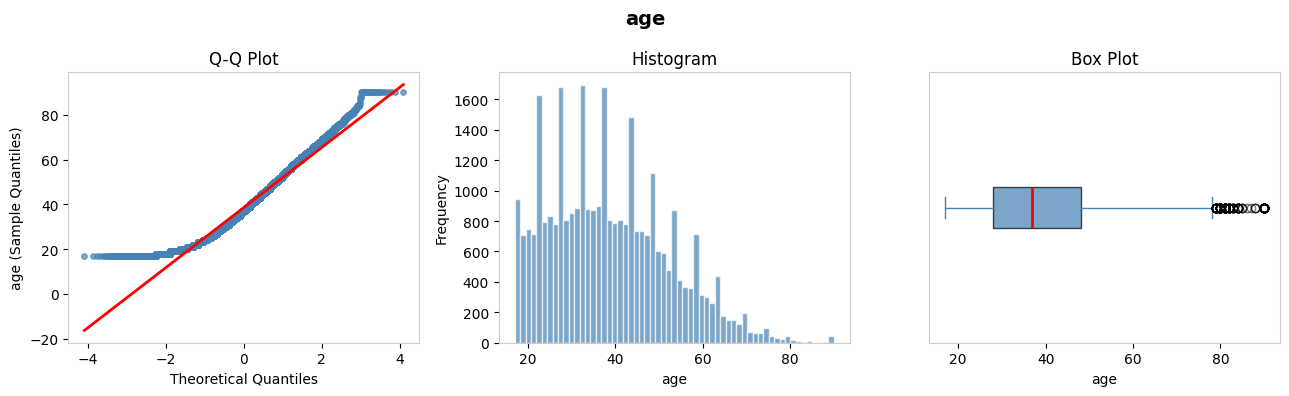

Column: age
Test: D'Agostino K²
Test Statistic: 1509.0843, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


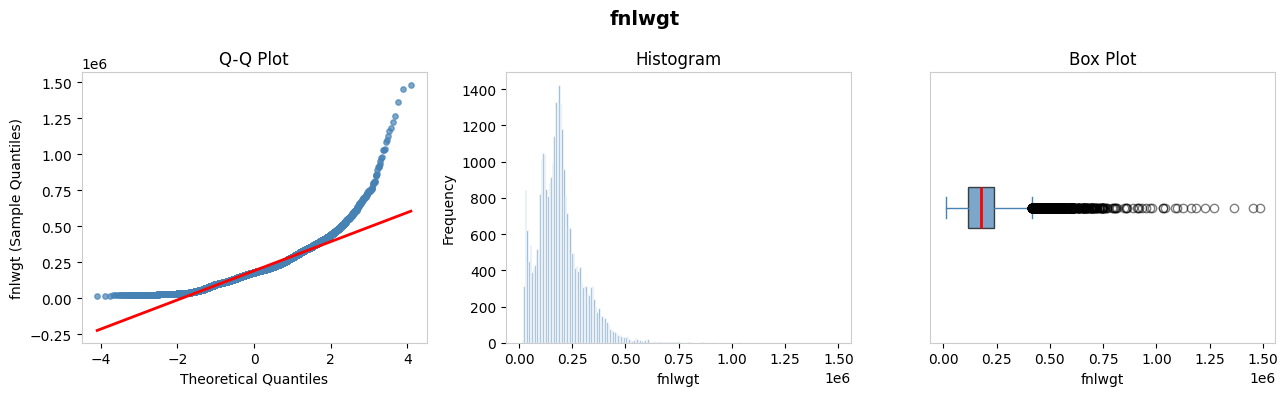

Column: fnlwgt
Test: D'Agostino K²
Test Statistic: 10650.7128, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


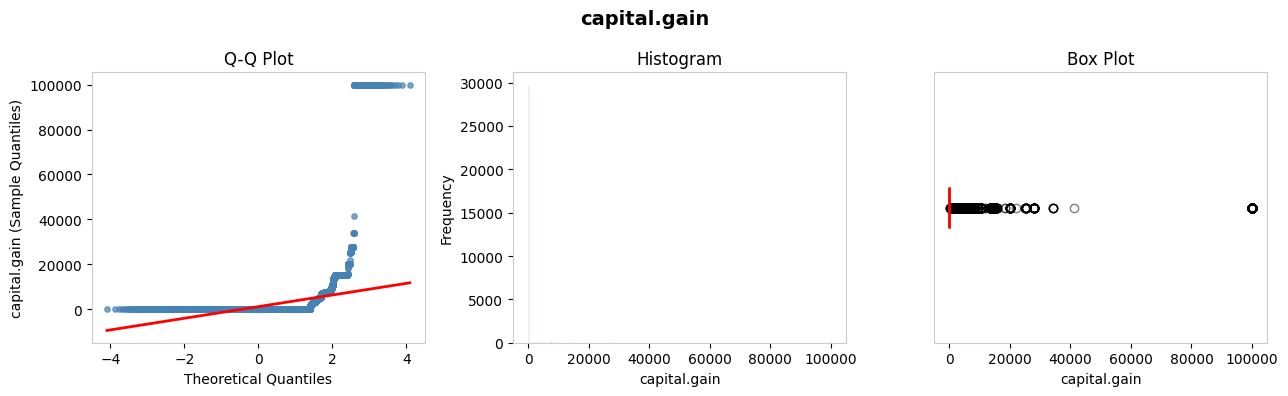

Column: capital.gain
Test: D'Agostino K²
Test Statistic: 54771.2016, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


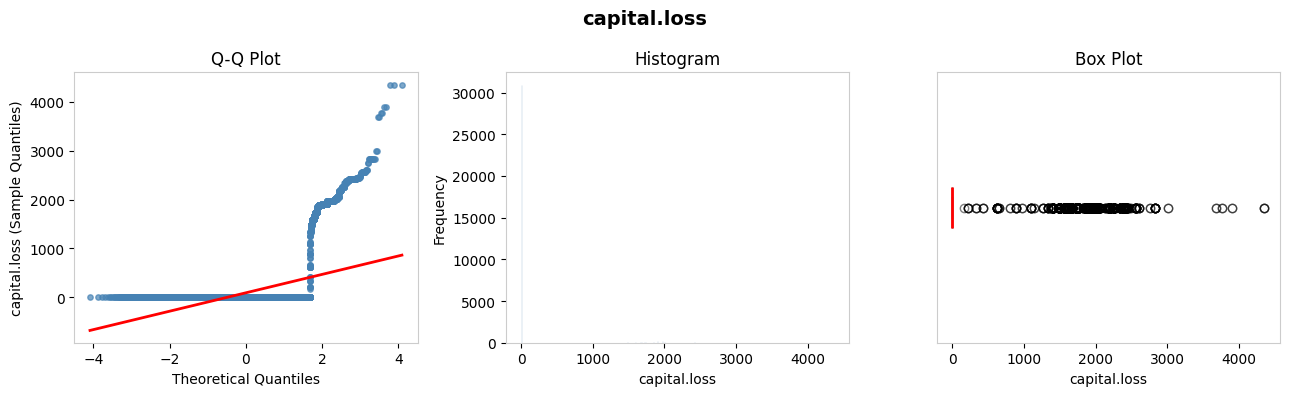

Column: capital.loss
Test: D'Agostino K²
Test Statistic: 29133.6008, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


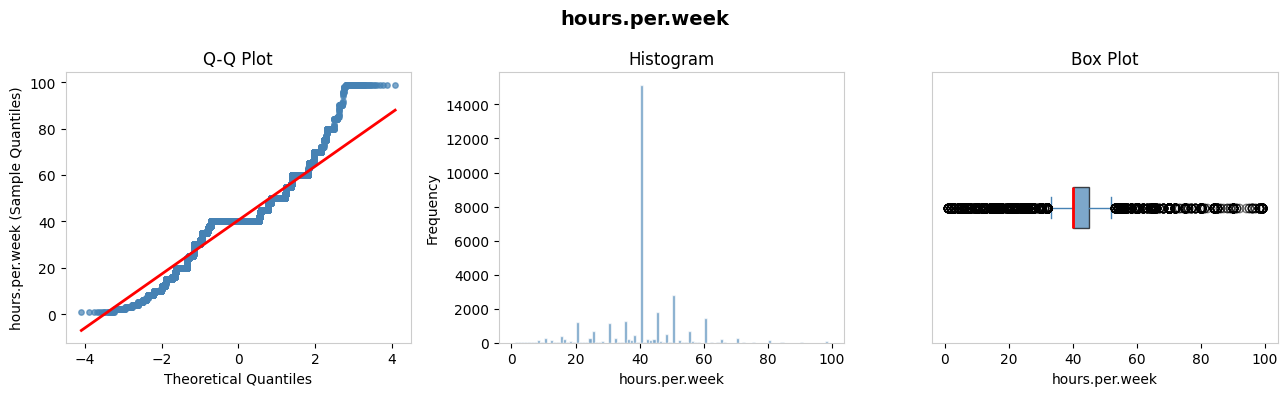

Column: hours.per.week
Test: D'Agostino K²
Test Statistic: 2476.1178, p-value: 0.0000
Result: Based on the D'Agostino K² test (p=0.0000 ≤ 0.05), 
the sample does not appear Gaussian. However, please verify using the visuals above before making a final decision. 
To override, pass result_dict={'col_name': 'Normal/Non-normal'} to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Note: The results above are based on statistical tests only. 
Please verify using the visuals before making a final decision. 
To manually set normality, pass result_dict={'col_name': 'Normal/Non-normal'} 
to num_summary().
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Columns flagged as Non-normal by the test — please verify visually: ['age', 'fnlwgt', '

In [36]:
cols=eda.check_num(plot=True,width_for_graph=13,height_for_graph=4)

 To validate our initial findings, we conducted a deeper assessment using a combination of visual diagnostics—specifically histograms, Q-Q plots, and box plots—alongside formal statistical tests. The results comprehensively confirm that all numerical features follow a non-normal distribution. 

 While almost every column exhibits standard data variability and outliers that could be considered natural for this type of population, `capital.gain` and `capital.loss` stand out significantly. The visualizations highlight extreme, heavy-tailed anomaly patterns in these two features, further reinforcing that they represent a distinct structural subset within the data rather than typical statistical noise.

In [37]:
dict_={}
for i in range(len(cols)):
    dict_[cols[i]]='Non-normal'
dict_

{'age': 'Non-normal',
 'fnlwgt': 'Non-normal',
 'capital.gain': 'Non-normal',
 'capital.loss': 'Non-normal',
 'hours.per.week': 'Non-normal'}

In [38]:
eda.num_summary(result_dict=dict_)

,Column,Result
0,age,Non-normal
1,fnlwgt,Non-normal
2,capital.gain,Non-normal
3,capital.loss,Non-normal
4,hours.per.week,Non-normal


In [39]:
outlier_report=eda.check_outlier(iqr_th=1.5
                                 ,q1_th=0.04,q3_th=0.96,
                                 cap=True)


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                            Outlier Detection                                                                             
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Column: age | Method: IQR | Outliers: 0 (0.00%)
Column: fnlwgt | Method: IQR | Outliers: 16 (0.05%)
  → 'fnlwgt' capped at [-506356.5000, 939567.5000]
Column: capital.gain | Method: IQR | Outliers: 254 (0.78%)
  → 'capital.gain' capped at [-10947.0000, 18245.0000]
Column: capital.loss | Method: IQR | Outliers: 3 (0.01%)
  → 'capital.loss' capped at [-2385.0000, 3975.0000]
Column: hours.per.week | Method: IQR | Outliers: 0 (0.00%)


 To mitigate the impact of extreme outliers without losing valuable rows, we applied a percentile-based capping method (Winsorization). Specifically, we capped the feature distributions at the 4th ($0.04$) and 96th ($0.96$) percentiles. Any data points falling below the 4th percentile or exceeding the 96th percentile were compressed to these respective thresholds to ensure more stable model training.

In [40]:
df=eda.dataframe

## Target Column Analysis


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                Target Analysis with Categorical Variables                                                                
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


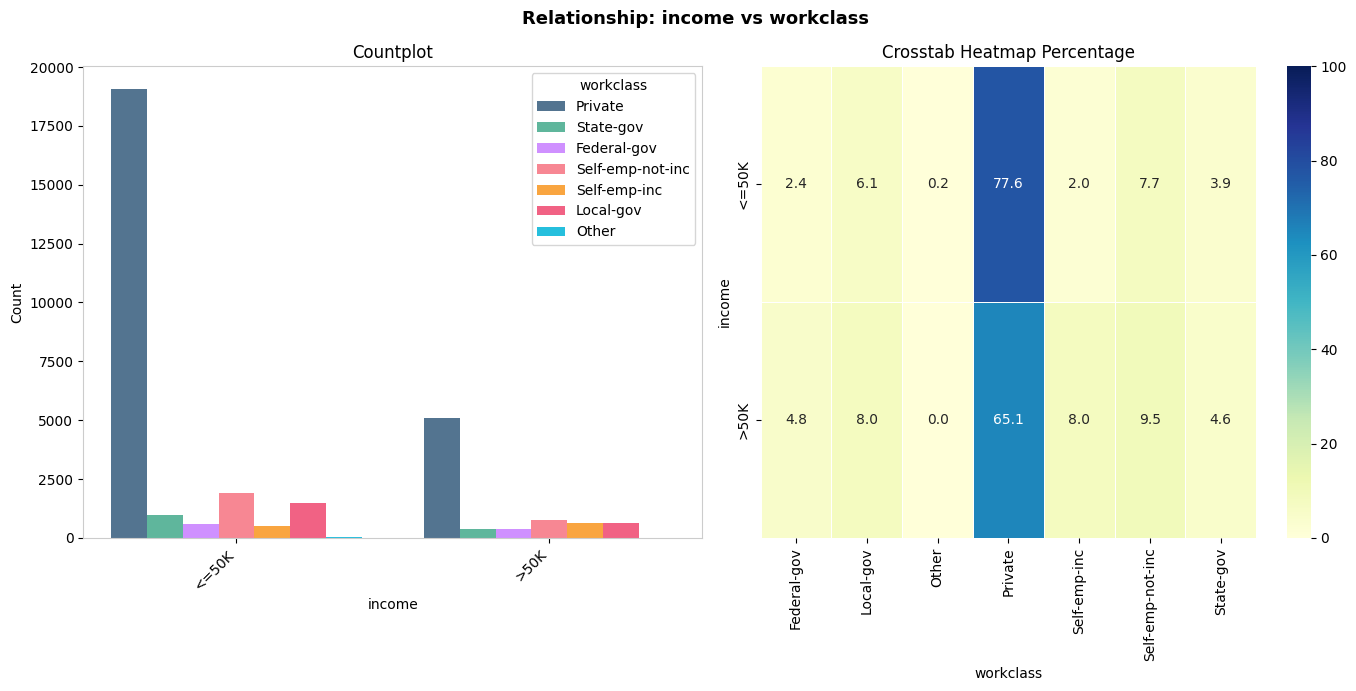


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 917.2354
p-value = 0.000000
df      = 6

Expected Values:
workclass  Federal-gov  Local-gov  Other  Private  Self-emp-inc  Self-emp-not-inc  State-gov
income                                                                                      
<=50K            740.5     1606.2   31.1  18337.2         854.3            2006.0     1000.7
>50K             235.5      510.8    9.9   5831.8         271.7             638.0      318.3 

Result:

→ H₀ REJECTED: There is a significa

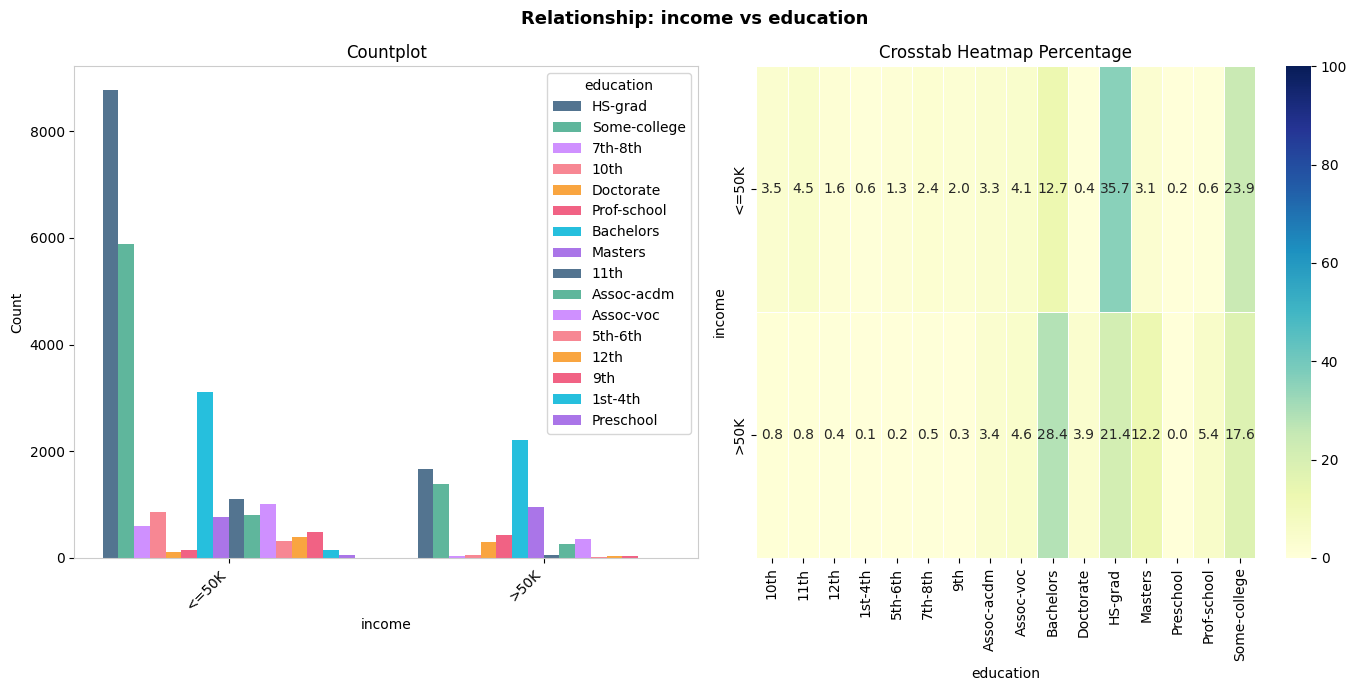


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 4420.7939
p-value = 0.000000
df      = 15

Expected Values:
education   10th   11th   12th  1st-4th  5th-6th  7th-8th    9th  Assoc-acdm  Assoc-voc  Bachelors  Doctorate  HS-grad  Masters  Preschool  Prof-school  Some-college
income                                                                                                                                                               
<=50K      706.4  886.9  323.2    121.4    245.8    486.3  385.4       807.3     104

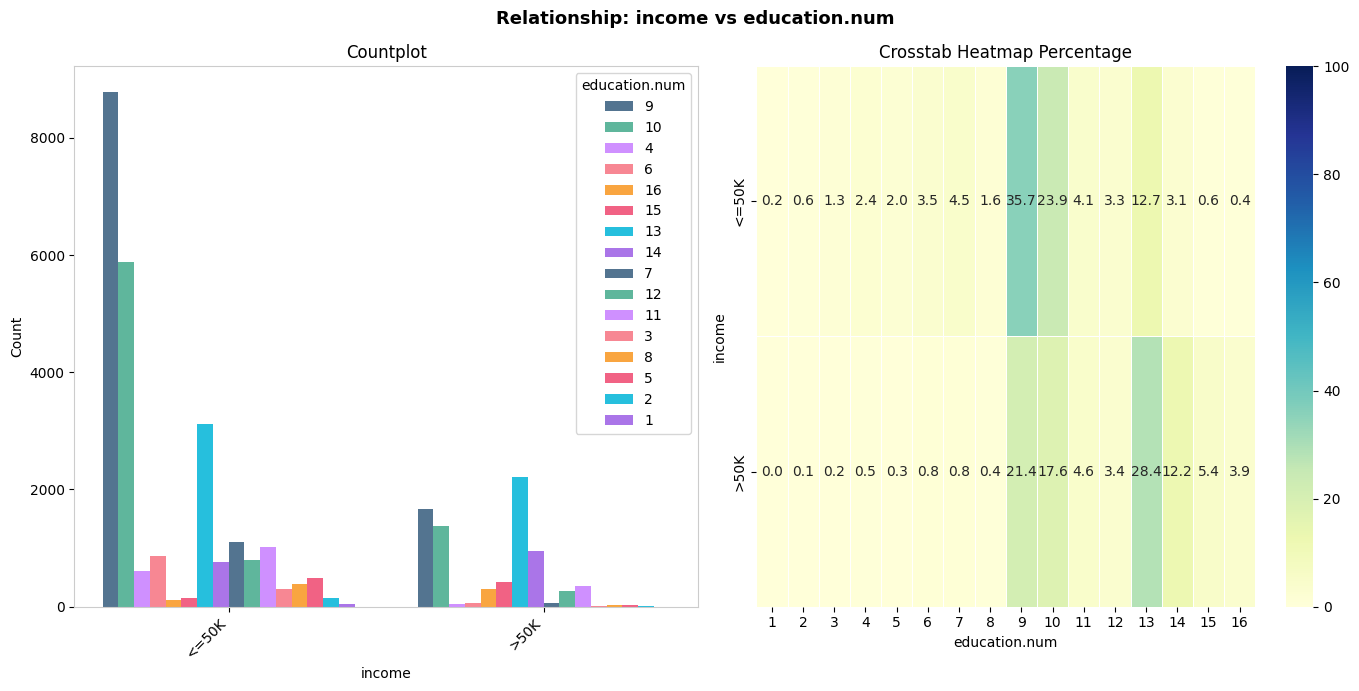


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 4420.7939
p-value = 0.000000
df      = 15

Expected Values:
education.num    1      2      3      4      5      6      7      8       9       10      11     12      13      14     15     16
income                                                                                                                           
<=50K          35.7  121.4  245.8  486.3  385.4  706.4  886.9  323.2  7930.0  5509.7  1043.2  807.3  4043.1  1302.7  436.3  312.6
>50K           11.3   38.6

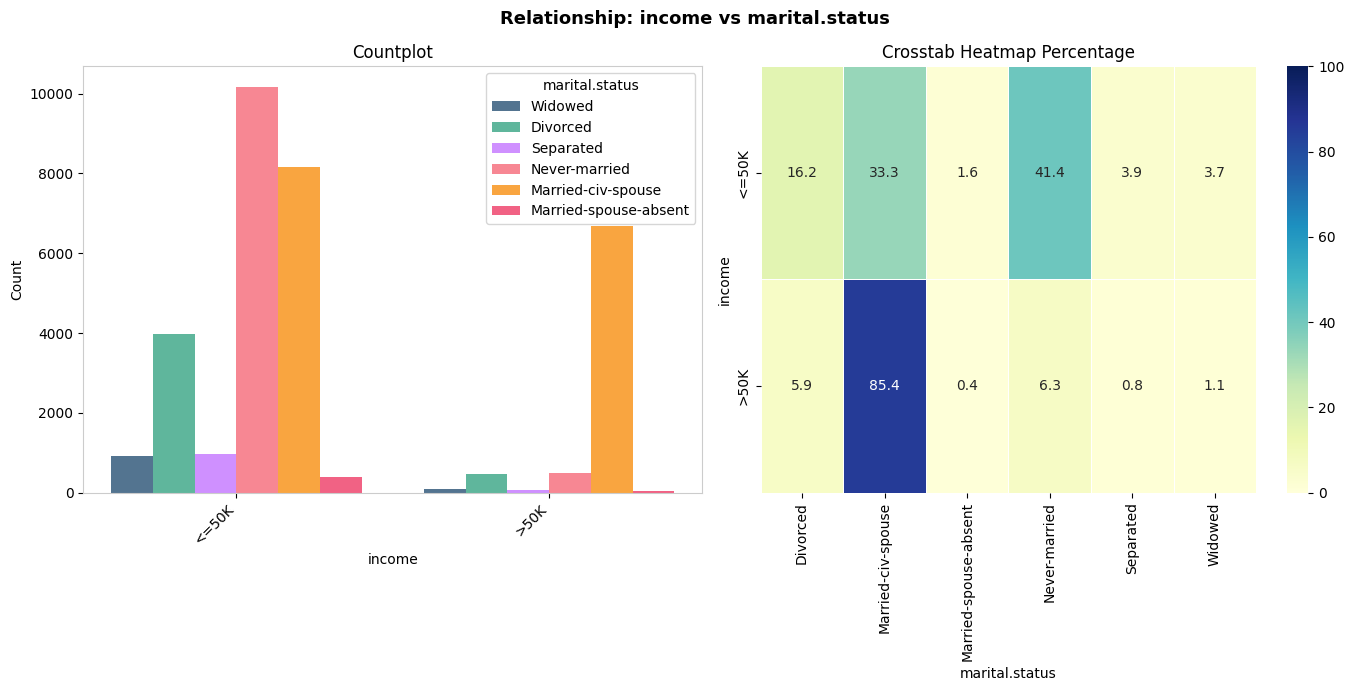


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 6563.5013
p-value = 0.000000
df      = 5

Expected Values:
marital.status  Divorced  Married-civ-spouse  Married-spouse-absent  Never-married  Separated  Widowed
income                                                                                                
<=50K             3369.4             11266.0                  317.1         8092.4      777.7    753.4
>50K              1071.6              3583.0                  100.9         2573.6      247.3    239.6 

Res

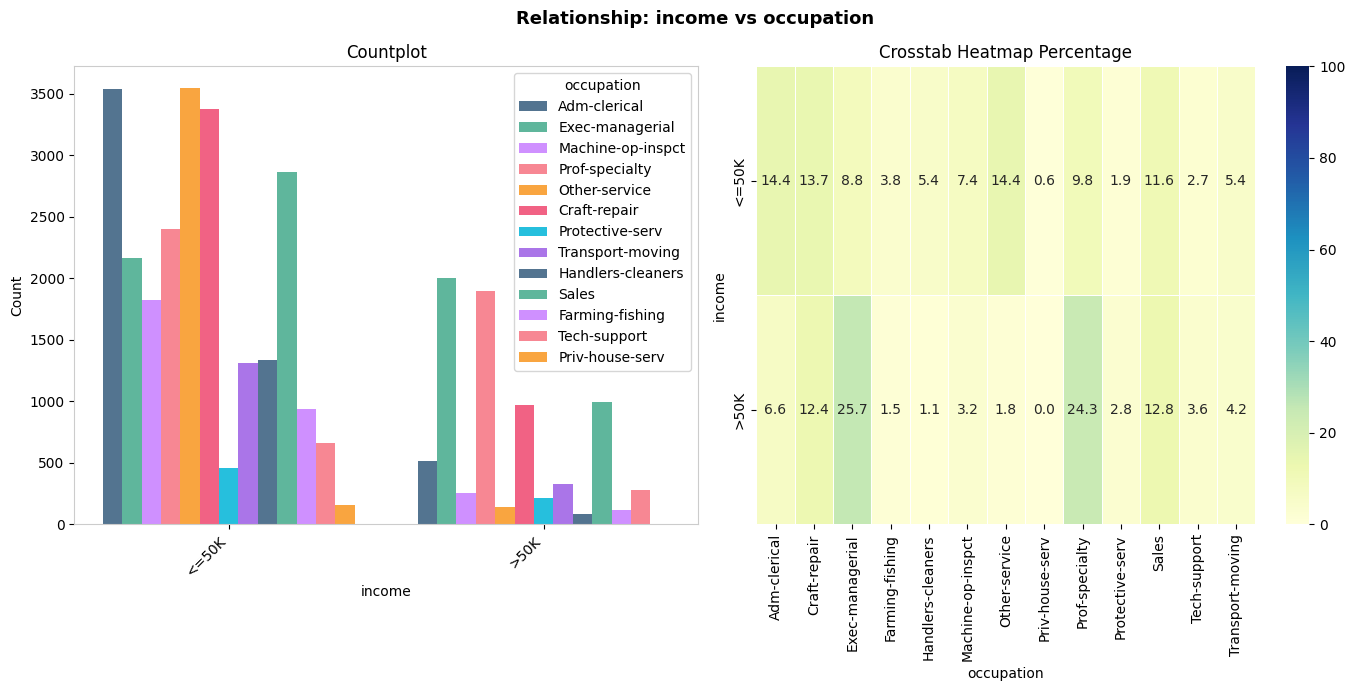


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 4000.5211
p-value = 0.000000
df      = 12

Expected Values:
occupation  Adm-clerical  Craft-repair  Exec-managerial  Farming-fishing  Handlers-cleaners  Machine-op-inspct  Other-service  Priv-house-serv  Prof-specialty  Protective-serv   Sales  Tech-support  Transport-moving
income                                                                                                                                                                                                  

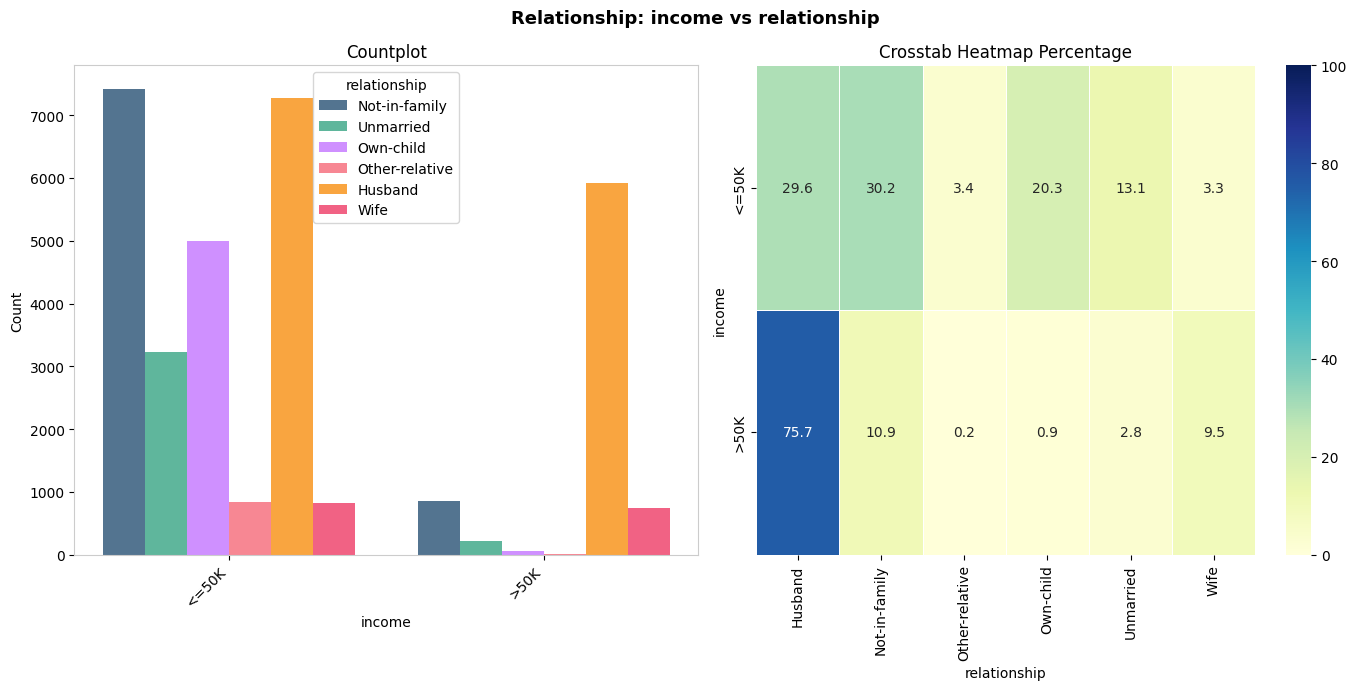


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 6689.2001
p-value = 0.000000
df      = 5

Expected Values:
relationship  Husband  Not-in-family  Other-relative  Own-child  Unmarried    Wife
income                                                                            
<=50K         10004.3         6278.3           650.2     3841.3     2613.7  1188.1
>50K           3181.7         1996.7           206.8     1221.7      831.3   377.9 

Result:

→ H₀ REJECTED: There is a significant relationship between income and rela

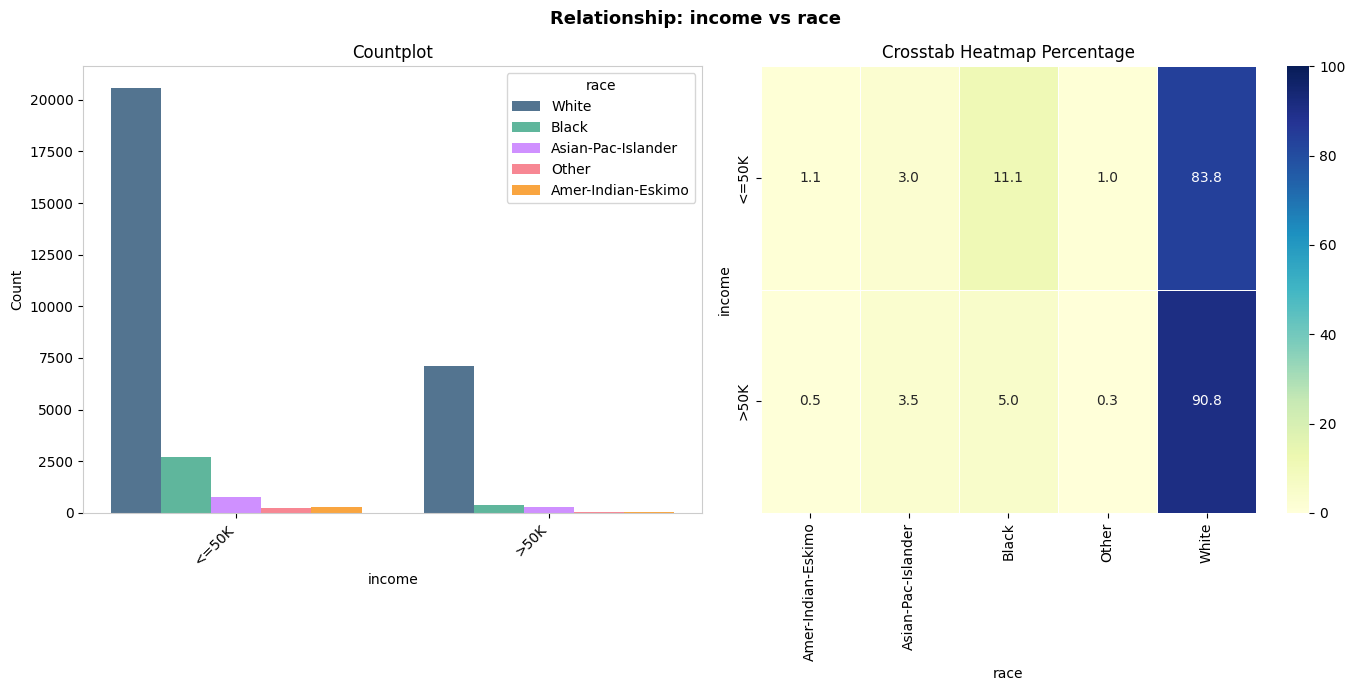


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 331.9556
p-value = 0.000000
df      = 4

Expected Values:
race    Amer-Indian-Eskimo  Asian-Pac-Islander   Black  Other    White
income                                                                
<=50K                234.4               772.4  2363.4  200.3  21005.5
>50K                  74.6               245.6   751.6   63.7   6680.5 

Result:

→ H₀ REJECTED: There is a significant relationship between income and race (p < 0.05)

────────────────────────────────────

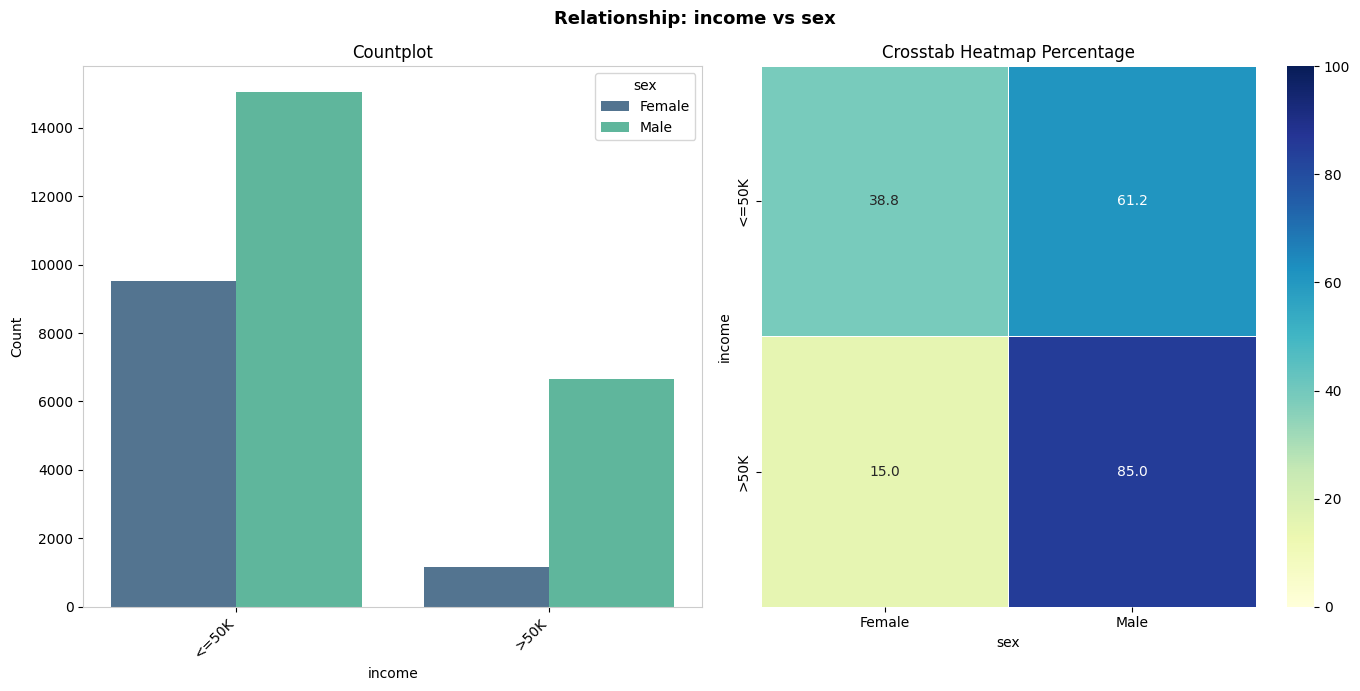


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                             Chi-Square Test                                                                              
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
χ²      = 1517.1984
p-value = 0.000000
df      = 1

Expected Values:
sex     Female     Male
income                 
<=50K   8119.7  16456.3
>50K    2582.3   5233.7 

Result:

→ H₀ REJECTED: There is a significant relationship between income and sex (p < 0.05)

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                     

In [41]:
eda.target_summary_with_cat(plot=True,width_for_graph=14,height_for_graph=7)

## Categorical Features vs. Target (`Income`) Bivariate Analysis

 To uncover the true relationships between our categorical features and the target variable (`income`), we conducted a bivariate analysis utilizing contingency tables (crosstabs). Given our large sample size, relying solely on the Chi-Square test's p-value is insufficient, as it easily triggers statistical significance. Therefore, we calculated **Cramer’s V** to measure the actual effect size (strength of association) and thoroughly compared the **Observed** counts against the **Expected** frequencies.

 1. Workclass (Weak to Moderate Association)
 While the `Private` sector remains the largest employer across both income brackets ($>50K$ and $\le50K$), looking at the expected vs. observed distribution reveals a clear trend:
 * `Self-emp-inc` exhibits a significantly higher proportion in the $>50K$ category than statistically expected. 
 * Federal, local, and state government employees, alongside `Self-emp-not-inc`, also show a strong tendency toward the $>50K$ threshold.
 * Conversely, the `Private` sector displays a higher-than-expected concentration within the $\le50K$ income bracket.

 2. Education (Moderate to Strong Association)
 As expected, education acts as a powerful predictor for income, demonstrating a strong positive correlation:
 * Higher education levels (`Bachelors`, `Masters`, `Doctorate`) show a distinct over-representation in the $>50K$ segment compared to lower education tiers like `HS-grad`.
 * This delta becomes progressively steeper with higher degrees; the ratio of $>50K$ to $\le50K$ earners among `Masters` and `Doctorate` holders vastly outpaces that of `Bachelors` graduates.

 3. Marital Status & Relationship (Moderate to Strong Association)
 Family structure and household roles reveal a massive socio-economic divide, suggesting that married individuals are heavily correlated with higher income categories:
 * **Marital Status:** Individuals categorized as `Never-married` are heavily compressed within the lower income tier ($\le50K$). In stark contrast, a disproportionately massive segment of the `Married-civ-spouse` cohort belongs to the $>50K$ bracket.
 * **Relationship:** Corroborating the marital status data, `Husband` and `Wife` roles both demonstrate higher-than-expected frequencies in the $>50K$ group. Meanwhile, the `Own-child` category peaks heavily within the lower income bracket and drops to the absolute lowest count in the higher tier.

 4. Occupation (Moderate to Strong Association)
 The job role analysis isolates specific highly compensated career tracks:
 * `Exec-managerial` and `Prof-specialty` positions are heavily dominant in the $>50K$ income tier.
 * `Tech-support` roles also outperform their statistically expected baseline, shifting notably toward the higher income bracket.
 * On the other hand, administrative and clerical roles (`Adm-clerical`) are heavily skewed toward the $\le50K$ category when compared to professional fields.

 5. Race & Sex (Weak to Moderate Association)
 Demographic variables show less intense, yet statistically present associations:
 * **Race:** The correlation is weak-to-moderate. Notably, the `Asian-Pac-Islander` demographic shows a higher representation in the $>50K$ tier relative to its expected value. This nuance likely reflects geographic or regional wage variances rather than an isolated racial variable.
 * **Sex:** Displays a weak-to-moderate association, with male individuals showing a higher observed frequency in the $>50K$ bracket than statistically expected.

*Note: All observations above are strictly backed by statistical effect sizes and residual analysis of contingency tables.*


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                 Target Analysis with Numerical Variables                                                                 
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
             mean median  count
              age    age    age
income                         
<=50K   36.796143   34.0  24576
>50K    44.277636   44.0   7816


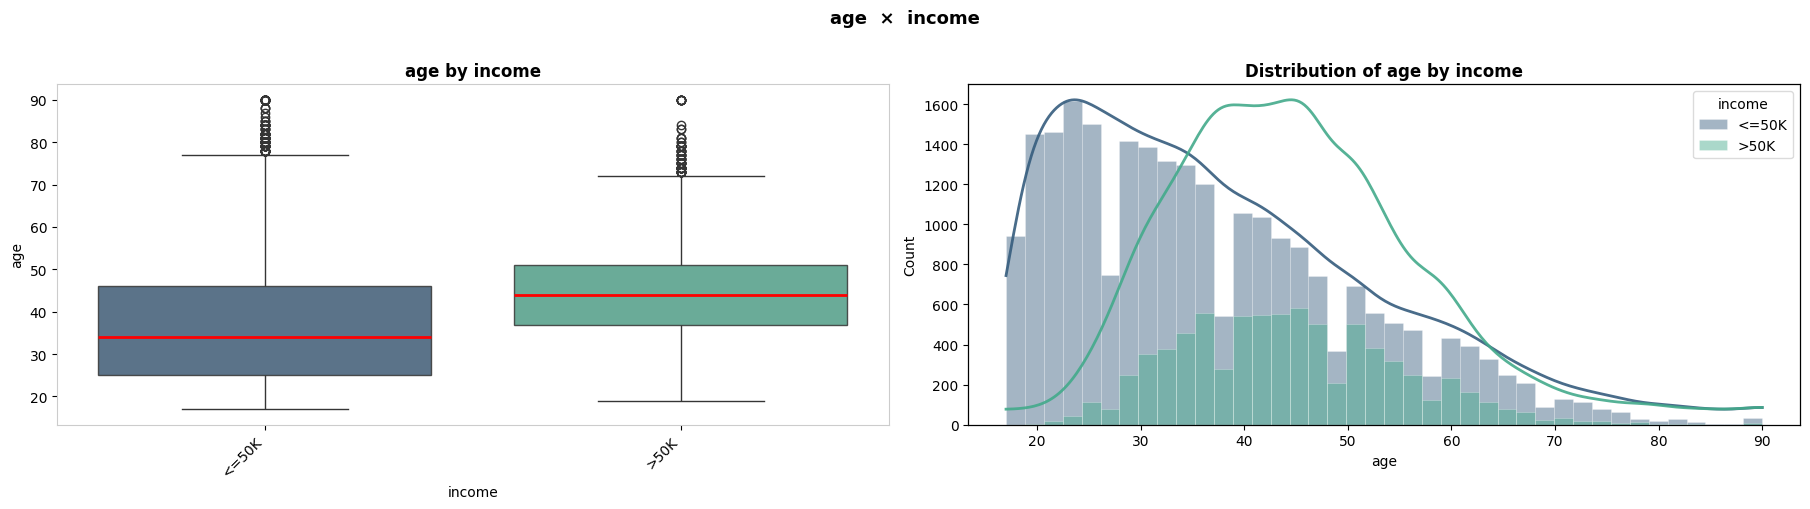


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P-value: 0.000000.
 H₀ REJECTED: Significant difference found.
Effect size r = 0.2735/Small — the difference is statistically significant but has minimal practical importance.
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                 mean    median  count
               fnlwgt    fnlwgt fnlwgt
income                                
<=50K   190174.199015  179423.0  24576
>50K    187827.029683  176050.0   7816


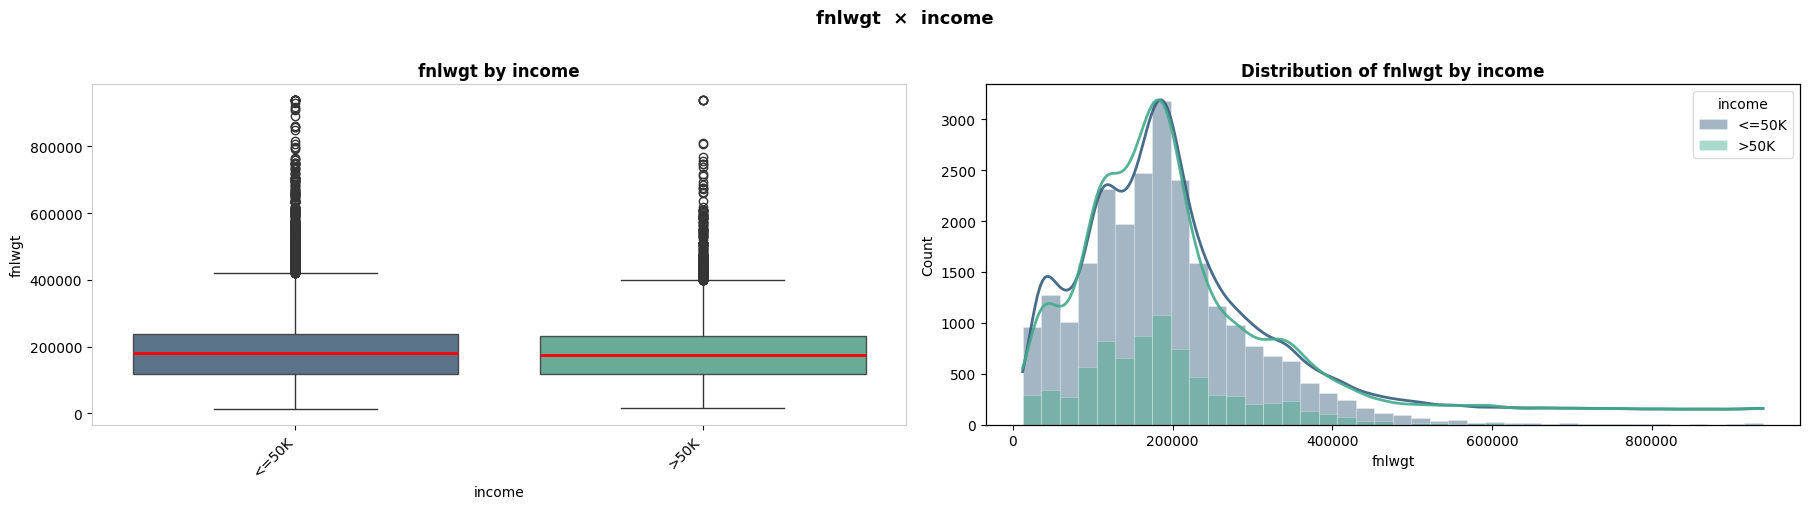


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P-value: 0.050630.
 H₀ ACCEPTED: No significant difference.
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
               mean       median        count
       capital.gain capital.gain capital.gain
income                                       
<=50K    142.728516          0.0        24576
>50K    2287.787615          0.0         7816


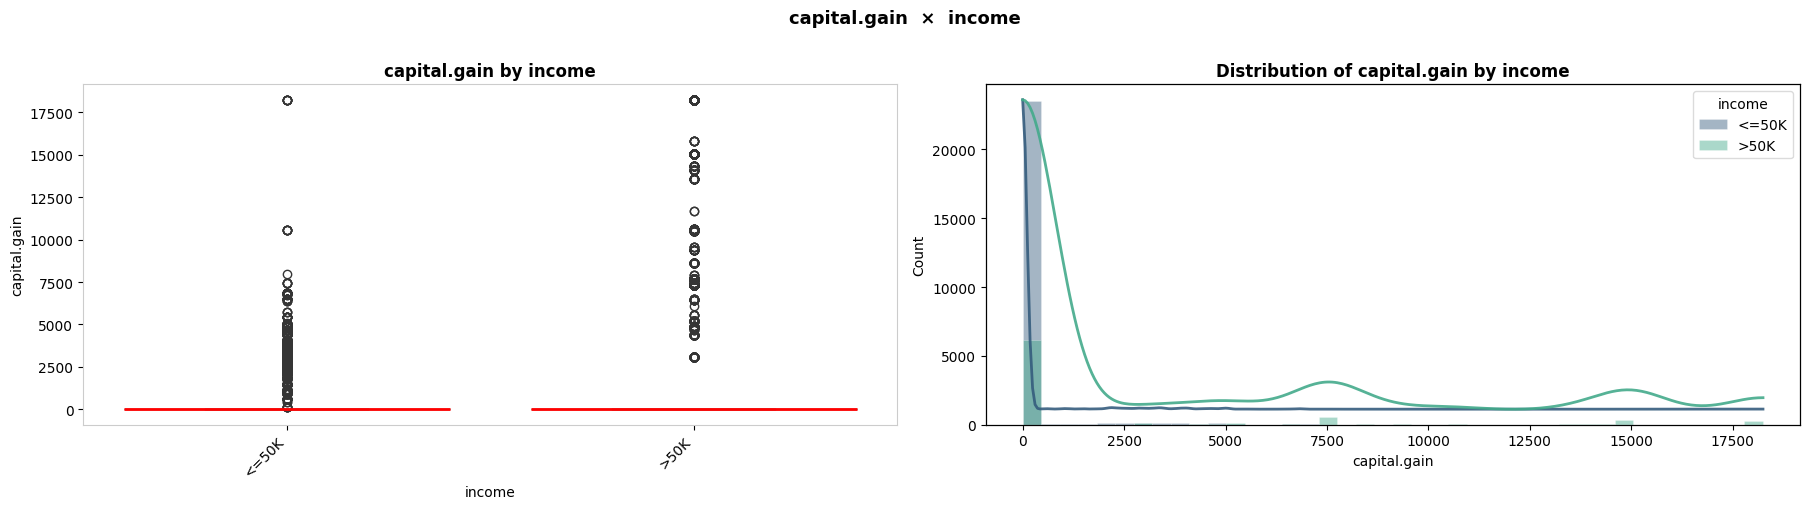


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P-value: 0.000000.
 H₀ REJECTED: Significant difference found.
Effect size r = 0.1336/Small — the difference is statistically significant but has minimal practical importance.
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
               mean       median        count
       capital.loss capital.loss capital.loss
income                                       
<=50K     53.237630          0.0        24576
>50K     195.337897          0.0         7816


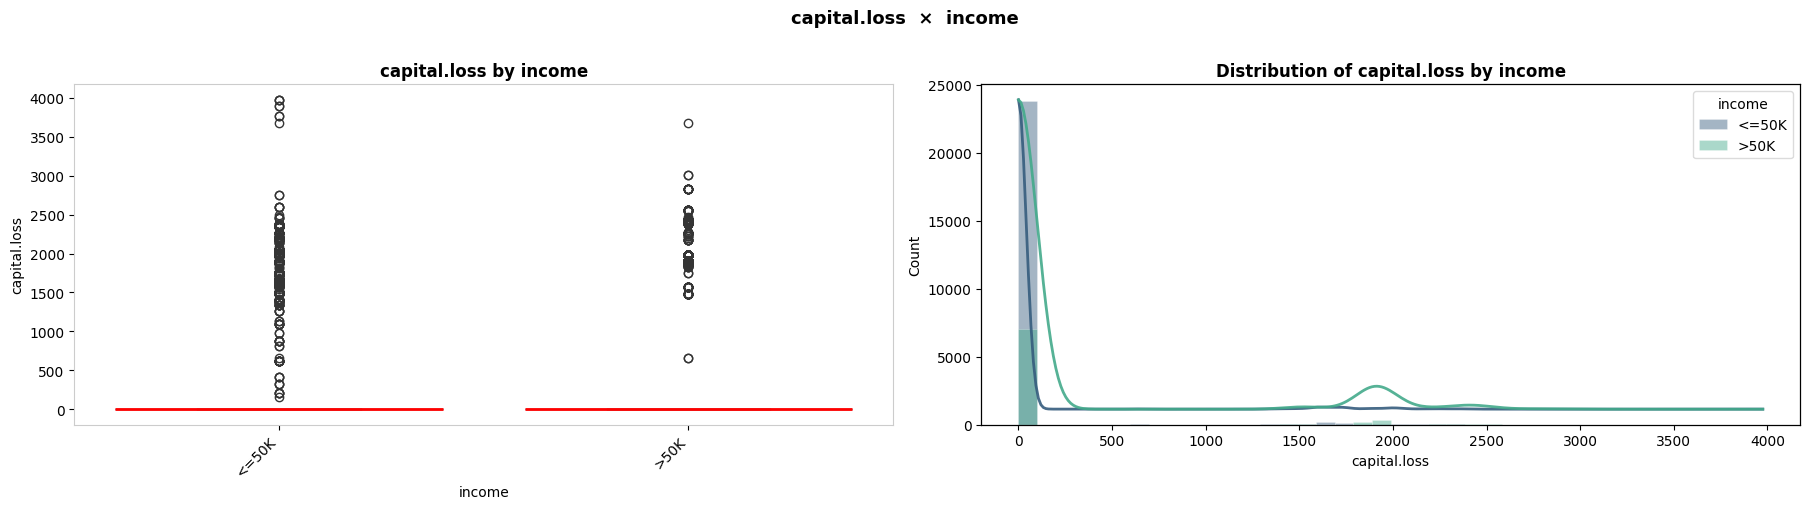


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P-value: 0.000000.
 H₀ REJECTED: Significant difference found.
Effect size r = 0.0516/Small — the difference is statistically significant but has minimal practical importance.
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                 mean         median          count
       hours.per.week hours.per.week hours.per.week
income                                             
<=50K       38.844360           40.0          24576
>50K        45.474667           40.0           7816


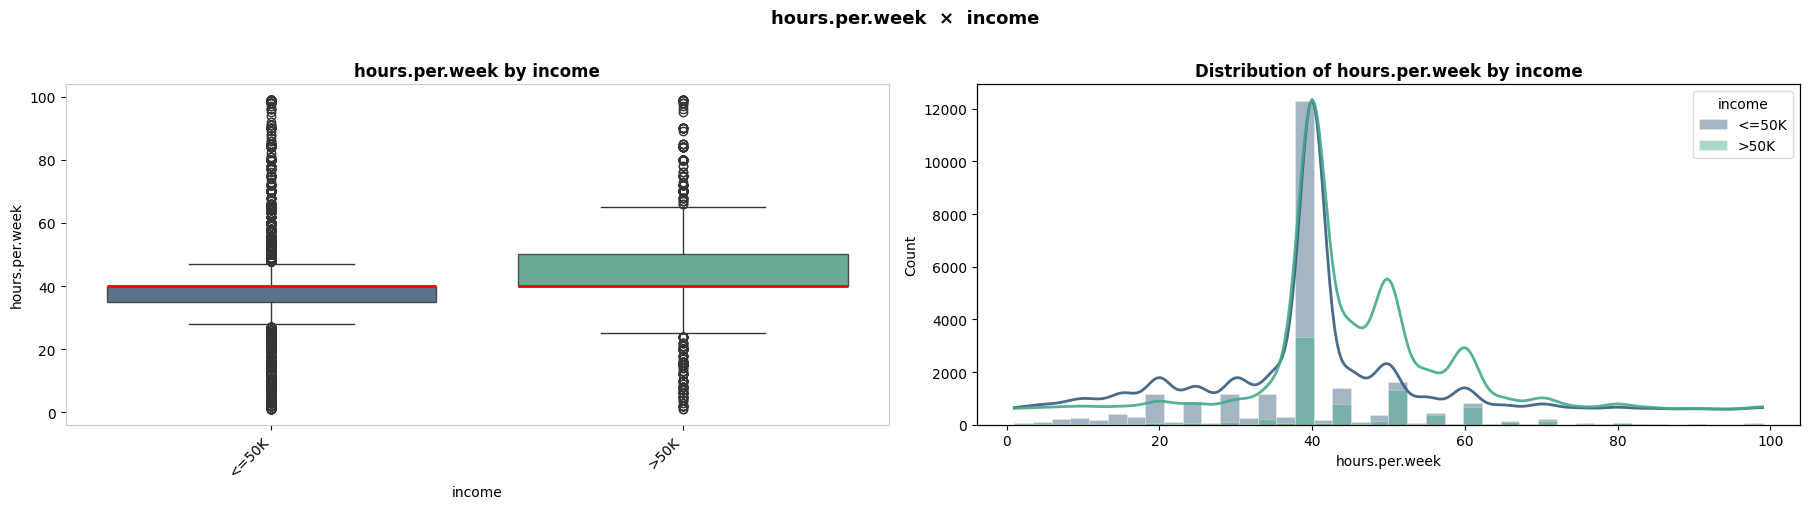


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
P-value: 0.000000.
 H₀ REJECTED: Significant difference found.
Effect size r = 0.2549/Small — the difference is statistically significant but has minimal practical importance.
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [42]:
eda.target_summary_with_num(plot=True)

## Numerical Features vs. Target (`Income`) Analysis

 In this section, we investigate the statistical relationships between the numerical features and our target variable (`income`). Given the substantial size of our dataset, relying solely on hypothesis test p-values is insufficient, as large sample sizes can artificially inflate significance. Therefore, we emphasize **Effect Size** metrics alongside our testing. Furthermore, since our earlier diagnostics confirmed that none of the numerical features follow a normal distribution, we employ the non-parametric **Mann-Whitney U** test for our comparisons.

 1. Age (Small Effect Size)
 There is a statistically observable, albeit small, relationship between age and income. As age increases, the probability of transitioning into the $>50K$ income bracket rises. This aligns with standard economic patterns where professional experience and seniority accumulate over time.

 2. Fnlwgt (No Association)
 The effect size between `fnlwgt` (final weight) and income is practically zero. This is the theoretically expected outcome, as `fnlwgt` represents the demographic sampling weight (the number of people the row represents in the census population). It is a purely administrative metric and should possess no inherent predictive power over an individual's earning capacity.

 3. Capital Gain & Capital Loss (Contextual Association)
 While the overall statistical effect size for these features appears lower compared to other variables, a deeper look reveals a structural sub-pattern:
 * Our descriptive analysis showed that the median and even the 75th percentile ($Q_3$) for both columns are exactly 0, confirming that the vast majority of the population does not engage in capital investments.
 * However, when comparing the averages, the mean values for both `capital_gain` and `capital_loss` are significantly higher within the $>50K$ income bracket. 
 * This indicates that extreme outliers (high-value capital events) are heavily concentrated among top earners. The presence of high capital losses in the $>50K$ bracket suggests that these individuals are actively investing capital; since the range of capital gains is much wider than losses, these high earners absorb losses as part of a larger investment portfolio. Ultimately, capital-related activities are almost exclusively tied to higher-income brackets.

 4. Hours per Week (Small to Moderate Association)
 The number of working hours per week shares a clear relationship with the income target. Although the effect size is not massive, individuals in the $>50K$ segment exhibit a higher average of weekly working hours compared to those earning $\le50K$. Working longer hours remains a steady, statistically verifiable factor in reaching the higher income tier.

*Note: All findings are substantiated by Mann-Whitney U test statistics and non-parametric effect size calculations.*

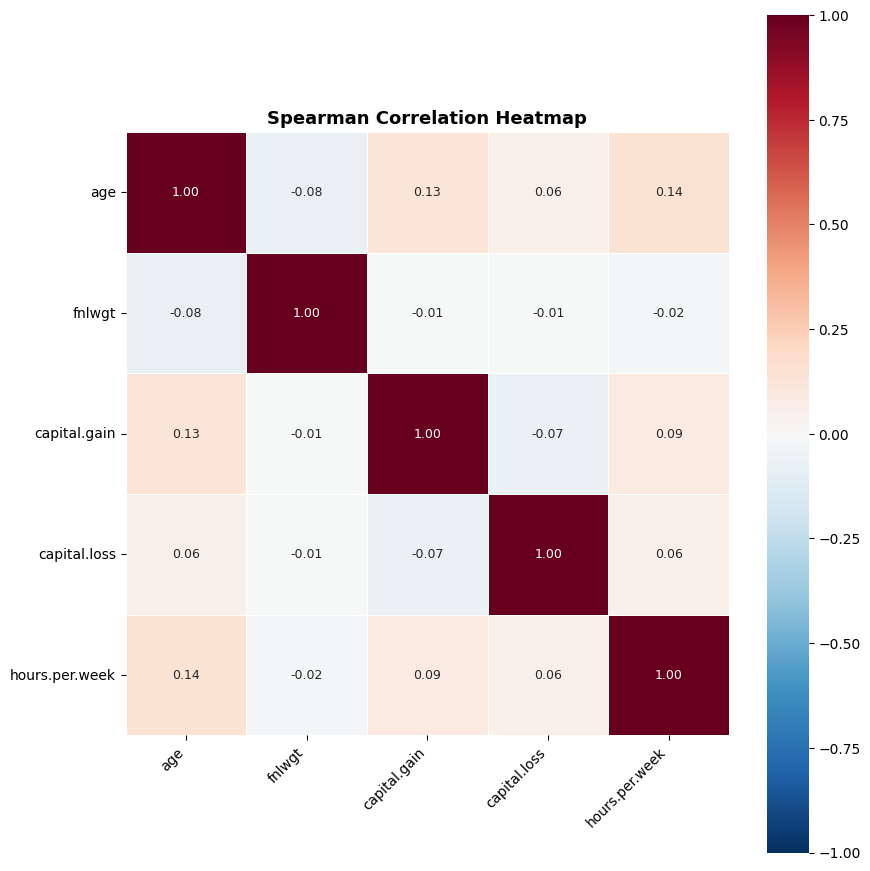

In [43]:
eda.correlation_heatmap()